# Helpers

In [1]:
import json
import re
import random
import statistics
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
_RUN_RE = re.compile(
    r"llama_drop_only_(?P<month>adzuna_month\d{2})_(?P<start>\d+)_(?P<stop>\d+)_job(?P<jobid>\d+)_task(?P<taskid>\d+)_\d{8}_\d{6}\.jsonl$"
)

IT_PATTERNS = [
    r"\bsoftware\b", r"\bdeveloper\b", r"\bengineer\b", r"\bdata\b", r"\bml\b", r"\bai\b",
    r"\bcloud\b", r"\bcyber\b", r"\bsecurity\b", r"\bnetwork\b", r"\bsystems?\b",
    r"\bdatabase\b", r"\bit\b", r"\bdevops\b"
]
_IT_RE = re.compile("|".join(IT_PATTERNS), flags=re.I)

def _is_it_role(title: str) -> bool:
    if not title:
        return False
    return bool(_IT_RE.search(title))


def _infer_npz_from_jsonl(jsonl_path: Path) -> Path:
    """
    NEW layout:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>/llama_drop_only_....jsonl
    NPZ sits at:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>.npz
    """
    m = _RUN_RE.search(jsonl_path.name)
    if not m:
        raise ValueError(f"JSONL filename doesn't match expected pattern: {jsonl_path.name}")

    month = m.group("month")
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    return embed_root / f"{month}.npz"


def _get_job_ids(z) -> np.ndarray:
    """
    Supports both schemas:
      new: job_ids
      old: job_id
    Returns np.ndarray[str]
    """
    if "job_ids" in z.files:
        return z["job_ids"].astype(str)
    if "job_id" in z.files:
        return z["job_id"].astype(str)
    raise KeyError(f"NPZ missing job id key. Need job_ids or job_id. Have={sorted(z.files)}")


def _load_npz_lookup(npz_path: Path):
    """
    Expects stage3-prep NPZ keys (canonical):
      job_ids (or job_id), job_ad_title, job_desc, job_tasks, domain, job_sector_category, job_description
    """
    with np.load(npz_path, allow_pickle=True) as z:
        job_ids = _get_job_ids(z)

        # canonical (your stage3-prep)
        job_ad_title = z["job_ad_title"]
        job_desc = z["job_desc"]
        job_tasks = z["job_tasks"]

        domain = z["domain"] if "domain" in z.files else None
        job_sector_category = z["job_sector_category"] if "job_sector_category" in z.files else None
        job_description = z["job_description"] if "job_description" in z.files else None

    lookup = {}
    for i, jid in enumerate(job_ids):
        lookup[jid] = {
            "job_ad_title": None if job_ad_title[i] is None else str(job_ad_title[i]),
            "job_desc": None if job_desc[i] is None else str(job_desc[i]),
            "job_tasks": None if job_tasks[i] is None else str(job_tasks[i]),
            "job_description": None if job_description is None or job_description[i] is None else str(job_description[i]),
            "domain": None if domain is None or domain[i] is None else str(domain[i]),
            "job_sector_category": None if job_sector_category is None or job_sector_category[i] is None else str(job_sector_category[i]),
        }
    return lookup


# ---------------------------------------------------------------------
# Main: report generator
# ---------------------------------------------------------------------
def gen_report(jsonl_path: str, *, npz_path: str | None = None, sample_n: int = 30, seed: int = 0):
    """
    jsonl_path: path to llama_drop_only_*.jsonl
    npz_path  : optional explicit context NPZ. If None, inferred from jsonl name/dir.
    """
    random.seed(seed)

    jsonl_path = Path(jsonl_path)
    if not jsonl_path.exists():
        raise FileNotFoundError(f"Missing JSONL: {jsonl_path}")

    inferred_npz = _infer_npz_from_jsonl(jsonl_path)
    npz_path = Path(npz_path) if npz_path else inferred_npz
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing NPZ: {npz_path}")

    # report folder: put it under .../llm_negative_selection/<EMBED>/evaluation_reports/
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    report_dir = embed_root / "evaluation_reports"
    report_dir.mkdir(parents=True, exist_ok=True)

    print("JSONL:", jsonl_path)
    print("NPZ :", npz_path)
    print("OUT :", report_dir)

    lookup = _load_npz_lookup(npz_path)

    before_counts = []
    after_counts = []
    kept_titles = Counter()
    domain_kept = defaultdict(list)

    it_leak = 0
    total_kept = 0
    empty_outputs = 0

    samples = []
    seen_sample_ids = set()

    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                r = json.loads(line)
            except Exception:
                continue

            jid = str(r.get("job_id", "")).strip()
            if not jid:
                continue

            ctx = lookup.get(jid, {})

            cand = r.get("candidates") or []
            final = r.get("final") or []

            before_counts.append(len(cand))
            after_counts.append(len(final))

            if len(final) == 0:
                empty_outputs += 1

            for t in final:
                kept_titles[t] += 1
                total_kept += 1
                if _is_it_role(t):
                    it_leak += 1

            dom = ctx.get("domain") or "UNKNOWN"
            domain_kept[dom].append(len(final))

            # sample gate
            if len(samples) < sample_n and jid not in seen_sample_ids and random.random() < 0.05:
                seen_sample_ids.add(jid)
                samples.append({
                    "job_id": jid,
                    "job_ad_title": ctx.get("job_ad_title"),
                    "domain": ctx.get("domain"),
                    "sector": ctx.get("job_sector_category"),
                    "job_desc": ctx.get("job_desc"),
                    "kept": final,
                    "dropped": r.get("drop") or [],
                })

    if not before_counts:
        raise RuntimeError("No valid rows parsed from JSONL.")

    before_avg = statistics.mean(before_counts)
    after_avg = statistics.mean(after_counts)
    drop_rate = 1.0 - (after_avg / before_avg if before_avg else 0.0)
    it_share = it_leak / max(total_kept, 1)

    metrics = {
        "jobs": len(before_counts),
        "avg_candidates_before": round(before_avg, 3),
        "avg_candidates_after": round(after_avg, 3),
        "drop_rate": round(drop_rate, 4),
        "empty_outputs_percent": round(100.0 * empty_outputs / len(before_counts), 3),
        "it_leakage_share": round(it_share, 4),
        "min_kept": int(min(after_counts)),
        "max_kept": int(max(after_counts)),
    }

    domain_summary = {d: round(statistics.mean(v), 3) for d, v in domain_kept.items()}

    report = {
        "run": {
            "jsonl": str(jsonl_path),
            "npz": str(npz_path),
            "generated_at": datetime.now().isoformat(timespec="seconds"),
        },
        "global_metrics": metrics,
        "top_kept_roles": kept_titles.most_common(25),
        "domain_summary_avg_kept": dict(sorted(domain_summary.items(), key=lambda x: (-x[1], x[0]))),
        "sample_cases": samples,
    }

    base = jsonl_path.stem
    report_json = report_dir / f"{base}_report.json"
    report_txt = report_dir / f"{base}_report.txt"

    with report_json.open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    with report_txt.open("w", encoding="utf-8") as f:
        f.write("=== GLOBAL METRICS ===\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")

        f.write("\n=== TOP KEPT OCCUPATIONS ===\n")
        for title, cnt in kept_titles.most_common(25):
            f.write(f"{cnt}  {title}\n")

        f.write("\n=== DOMAIN AVG KEPT ===\n")
        for d, v in sorted(domain_summary.items(), key=lambda x: (-x[1], x[0])):
            f.write(f"{d}: {v}\n")

        f.write("\n=== SAMPLE CASES (truncated) ===\n")
        for s in samples[:10]:
            f.write(f"\njob_id: {s['job_id']}\n")
            f.write(f"title:  {s.get('job_ad_title')}\n")
            f.write(f"domain: {s.get('domain')} | sector: {s.get('sector')}\n")
            f.write(f"kept:   {s.get('kept')}\n")
            f.write(f"drop:   {s.get('dropped')}\n")

    print("\nSaved:")
    print(" ", report_json)
    print(" ", report_txt)

    return report_json, report_txt


# Prompt 2 - intermediary - Embeddings weight 0.6 tasks e 0.4 roles;

In [17]:
# ===== Prompt printer: EXACT wiring check (single row) =====

import numpy as np
from pathlib import Path

# ---- CONFIG ----
NPZ_PATH = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz")
ROW_IDX = 35  # Change this to inspect different samples

# ---- LOAD ----
data = np.load(NPZ_PATH, allow_pickle=True)

# Map keys
job_ad_titles = data["job_ad_title"]
job_tasks_arr = data["job_tasks"]
domains = data["domain"]
job_descs = data["job_desc"]
job_sector_categories = data["job_sector_category"]
job_full_ads = data["job_description"]
candidates_matrix = data["titles"]  # 2D array [N, K]

# ---- EXTRACT ROW ----
title = job_ad_titles[ROW_IDX]
domain = domains[ROW_IDX]
tasks = job_tasks_arr[ROW_IDX]
desc = job_descs[ROW_IDX]
category = job_sector_categories[ROW_IDX]
full_excerpt = job_full_ads[ROW_IDX]
row_candidates = candidates_matrix[ROW_IDX]

# Clean up tasks
if isinstance(tasks, (list, np.ndarray)):
    tasks_str = ", ".join([str(t) for t in tasks if t])
else:
    tasks_str = str(tasks)

# Format candidates as a 1-based numbered list
numbered_candidates = "\n".join([f"{i+1}) {cand}" for i, cand in enumerate(row_candidates) if cand])

# ---- BUILD PROMPT (verbatim logic) ----

full_block = (
    f"\nFULL AD EXCERPT (use only for concrete duties, tools, licences, ignore fluff):\n{str(full_excerpt)[:700]}\n"
    if full_excerpt else ""
)

prompt = f"""You are a Precise Occupation Specialist. Your goal is to DROP as many candidates as possible. Only an functional match survives.

Read the job context carefully.

JOB CONTEXT (priority order):
1) Job Title + Job Domain (primary anchor)
2) Job Tasks (evidence)
3) Job short description (evidence)
4) Job Category (weak evidence)
5) Raw job ad excerpt (noisy evidence)

Title: {title}
Job list of Tasks/Skills: {tasks_str}
Job Domain: {domain}
Job short description: {desc}
Job Category: {category}
{full_block}

RE-READ ANCHOR JOB CONTEXT:
Title: {title}
Domain: {domain}
Tasks/Skills: {tasks_str}

CANDIDATES (1-based)
{numbered_candidates}

DECISION GUIDELINES:

1) THE ANCHOR PROTECTION RULE (Priority):
Identify the candidate that most directly mirrors the Job Title. You are strictly forbidden from dropping a direct functional match (e.g., if the job is 'Android Developer', you MUST keep 'Software Developers').

2) FUNCTIONAL ALIGNMENT:
Only keep candidates where the day-to-day work (Tasks) matches the candidate occupation. If a candidate is only "vaguely related" or in the same industry but a different role, DROP IT.

3) SPECIFICITY HIERARCHY:
If a specific role (e.g., 'Hospitalist') and its parent category (e.g., 'Physician') are both present, keep the specific one and DROP the generic parent.

4) IT DOMAIN FILTER:
If the Domain is NOT IT, be skeptical of Software/Data roles unless the 'Tasks' section explicitly describes technical work like coding or system administration.

5) REASONABLE BUDGET (1-3):
Aim for the most concise list possible, ideally 2 or 3 roles. You may keep 3 only if they are distinct but equally valid functional matches. NEVER keep 5+.

OUTPUT FORMAT:
Return ONLY valid JSON. 
Example for a list where only the second candidate was the actual match:
{{"drop":[2,3,5,6,7,8,9,10]}}

AUDIT VERDICT:
Return ONLY JSON:
{{"drop":[2,3,5,7,8,9,10]}}
""".strip()

# ---- PRINT ----
print("-" * 30)
print(f"VERIFIED MAXIMUM AGGRESSION PROMPT (ROW {ROW_IDX}):")
print("-" * 30)
print(prompt)
print("-" * 30)

------------------------------
VERIFIED MAXIMUM AGGRESSION PROMPT (ROW 35):
------------------------------
You are a Precise Occupation Specialist. Your goal is to DROP as many candidates as possible. Only an functional match survives.

Read the job context carefully.

JOB CONTEXT (priority order):
1) Job Title + Job Domain (primary anchor)
2) Job Tasks (evidence)
3) Job short description (evidence)
4) Job Category (weak evidence)
5) Raw job ad excerpt (noisy evidence)

Title: Sommelier-Restaurant Gordon Ramsay
Job list of Tasks/Skills: [Hospitality & Catering] Assist the Head Sommelier with wine and beverage service Supervise setting up and clearing down after each service Recommend and sell wines to guests Engage with customers to deliver high levels of service Supervise wine and beverage service WSET certification Wine knowledge Customer service Communication Leadership
Job Domain: Hospitality & Catering
Job short description: [Hospitality & Catering] Sommelier for a Three Michelin 

# bge

In [18]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_bge.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)


JOBID: 2151825


In [21]:
import time, subprocess
from pathlib import Path

LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout.strip()
while True:
    print("\n=== squeue ===")
    sq = sh(f"squeue -j {jobid}")
    print(sq if sq else "<finished>")

    out_logs = sorted(LOG_DIR.glob(f"*{jobid}*.out"))
    err_logs = sorted(LOG_DIR.glob(f"*{jobid}*.err"))

    if out_logs:
        print("\n--- STDOUT ---")
        print(sh(f"tail -n 20 {out_logs[-1]}"))

    if err_logs:
        print("\n--- STDERR ---")
        print(sh(f"tail -n 20 {err_logs[-1]}"))

    if not sq:
        break

    time.sleep(5)



=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2151825 autonomyluiz     workq z_llama_drop_new_test_bg  R    6:00:00       0:55    5:59:05     1 nid010564

--- STDOUT ---
[CFG] OUT_DIR: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01
[CFG] OUT_JSONL: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714.jsonl
[ENV] torch: 2.9.1+cu126
[ENV] cuda available: True
[ENV] gpu: NVIDIA GH200 120GB
[LOAD] npz: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz
[RANGE] 0:1000 (n=1000) -> 1000 jobs
[MODEL] snapshot: /projects/a5u/adu_dev/aisi-economy-index/hf_cache/models--meta-llama--Meta-Ll

KeyboardInterrupt: 

In [25]:
gen_report("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714.jsonl")

#from pathlib import Path
p = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/")
latest = max(p.glob("llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714_report.txt"), key=lambda x: x.stat().st_mtime)
print(latest.read_text())

JSONL: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714.jsonl
NPZ : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz
OUT : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports

Saved:
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714_report.json
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714_report.txt
=== GLOBAL METRICS ===
jobs: 10

### e5

In [19]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_e5.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)


JOBID: 2151826


In [26]:
import time, subprocess
from pathlib import Path

LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout.strip()
while True:
    print("\n=== squeue ===")
    sq = sh(f"squeue -j {jobid}")
    print(sq if sq else "<finished>")

    out_logs = sorted(LOG_DIR.glob(f"*{jobid}*.out"))
    err_logs = sorted(LOG_DIR.glob(f"*{jobid}*.err"))

    if out_logs:
        print("\n--- STDOUT ---")
        print(sh(f"tail -n 20 {out_logs[-1]}"))

    if err_logs:
        print("\n--- STDERR ---")
        print(sh(f"tail -n 20 {err_logs[-1]}"))

    if not sq:
        break

    time.sleep(5)



=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)

--- STDOUT ---
[DBG] category: 'Healthcare & Nursing Jobs'
[DBG] desc_head: '[Healthcare] Locum Consultant Physician - Care of the Elderly'
[DBG] tasks_head: '[Healthcare] Provide high-quality medical care to elderly patients Develop and i'
[DBG] job_id: 2789319749
[DBG] title: 'Apprentice Nursery Assistant'
[DBG] domain: 'Education'
[DBG] category: 'Teaching Jobs'
[DBG] desc_head: '[Education] Apprentice Nursery Assistant'
[DBG] tasks_head: '[Education] Interact with children in an appropriate and structured way Play alo'
[DBG] job_id: 2817223307
[DBG] title: 'IT Strategy & Transformation Consultant'
[DBG] domain: 'IT and Consulting'
[DBG] category: 'IT Jobs'
[DBG] desc_head: '[IT and Consulting] IT Strategy & Transformation Consultant'
[DBG] tasks_head: '[IT and Consulting] Help organisations source and deliver infrastructure Support'
[DONE] wrote: /projec

KeyboardInterrupt: 

In [28]:
#gen_report("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151826_task0_20260205_062733.jsonl")

from pathlib import Path
p = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/evaluation_reports/")
latest = max(p.glob("llama_drop_only_adzuna_month01_0_1000_job2151826_task0_20260205_062733_report.json"), key=lambda x: x.stat().st_mtime)
print(latest.read_text())


{
  "run": {
    "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151826_task0_20260205_062733.jsonl",
    "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz",
    "generated_at": "2026-02-05T06:32:53"
  },
  "global_metrics": {
    "jobs": 1000,
    "avg_candidates_before": 8.618,
    "avg_candidates_after": 3,
    "drop_rate": 0.6519,
    "empty_outputs_percent": 0.0,
    "it_leakage_share": 0.0613,
    "min_kept": 3,
    "max_kept": 3
  },
  "top_kept_roles": [
    [
      "Software Quality Assurance Analysts and Testers",
      50
    ],
    [
      "Accountants and Auditors",
      49
    ],
    [
      "Software Developers",
      46
    ],
    [
      "Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products",
      43
 

## GTE

In [20]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_gte.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)


JOBID: 2151827


In [32]:
import time, subprocess
from pathlib import Path

LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout.strip()
jobid=2151827
while True:
    print("\n=== squeue ===")
    sq = sh(f"squeue -j {jobid}")
    print(sq if sq else "<finished>")

    out_logs = sorted(LOG_DIR.glob(f"*{jobid}*.out"))
    err_logs = sorted(LOG_DIR.glob(f"*{jobid}*.err"))

    if out_logs:
        print("\n--- STDOUT ---")
        print(sh(f"tail -n 20 {out_logs[-1]}"))

    if err_logs:
        print("\n--- STDERR ---")
        print(sh(f"tail -n 20 {err_logs[-1]}"))

    if not sq:
        break

    time.sleep(5)



=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)

--- STDOUT ---
[DBG] category: 'Healthcare & Nursing Jobs'
[DBG] desc_head: '[Healthcare] Locum Consultant Physician - Care of the Elderly'
[DBG] tasks_head: '[Healthcare] Provide high-quality medical care to elderly patients Develop and i'
[DBG] job_id: 2789319749
[DBG] title: 'Apprentice Nursery Assistant'
[DBG] domain: 'Education'
[DBG] category: 'Teaching Jobs'
[DBG] desc_head: '[Education] Apprentice Nursery Assistant'
[DBG] tasks_head: '[Education] Interact with children in an appropriate and structured way Play alo'
[DBG] job_id: 2817223307
[DBG] title: 'IT Strategy & Transformation Consultant'
[DBG] domain: 'IT and Consulting'
[DBG] category: 'IT Jobs'
[DBG] desc_head: '[IT and Consulting] IT Strategy & Transformation Consultant'
[DBG] tasks_head: '[IT and Consulting] Help organisations source and deliver infrastructure Support'
[DONE] wrote: /projec

KeyboardInterrupt: 

In [34]:
gen_report("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151827_task0_20260205_062736.jsonl")

#from pathlib import Path
p = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/evaluation_reports/")
latest = max(p.glob("llama_drop_only_adzuna_month01_0_1000_job2151827_task0_20260205_062736_report.json"), key=lambda x: x.stat().st_mtime)
print(latest.read_text())


JSONL: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151827_task0_20260205_062736.jsonl
NPZ : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01.npz
OUT : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/evaluation_reports

Saved:
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2151827_task0_20260205_062736_report.json
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2151827_task0_20260205_062736_report.txt
{
  "run": {
    "jsonl": "/pro

Analyzing 1000 common jobs across models...
Saved Heatmap: model_agreement_heatmap.png
Saved Venn: model_overlap_venn.png

=== TOP DISAGREEMENTS (E5 vs BGE) ===
Job ID: 2737646584
  E5 Kept : {'Transportation, Storage, and Distribution Managers', 'Packers and Packagers, Hand', 'Cargo and Freight Agents'}
  BGE Kept: {'Packers and Packagers, Hand', 'Mobile Heavy Equipment Mechanics, Except Engines', 'Logistics Engineers'}
------------------------------
Job ID: 2793062487
  E5 Kept : {'Transportation, Storage, and Distribution Managers', 'Logistics Analysts', 'Shipping, Receiving, and Inventory Clerks'}
  BGE Kept: {'Transportation, Storage, and Distribution Managers', 'Stockers and Order Fillers', 'Cooling and Freezing Equipment Operators and Tenders'}
------------------------------
Job ID: 2828218071
  E5 Kept : {'Nurse Practitioners', 'Registered Nurses', 'Critical Care Nurses'}
  BGE Kept: {'Licensed Practical and Licensed Vocational Nurses', 'Registered Nurses', 'Acute Care Nurses'}

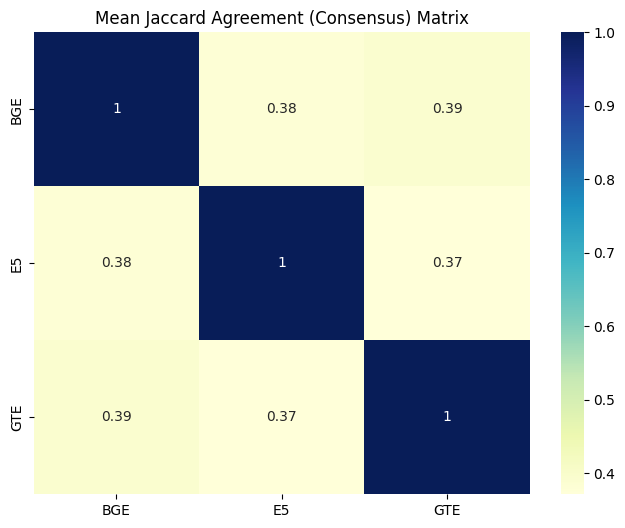

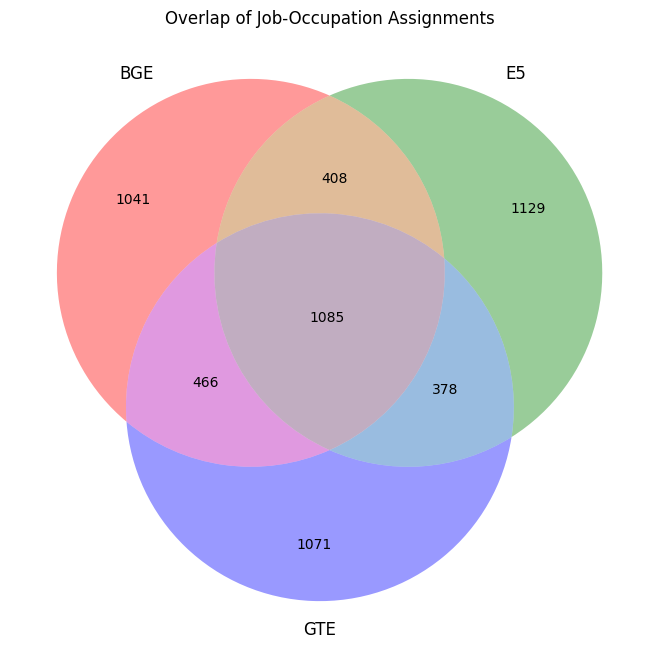

In [37]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from pathlib import Path

# ---- CONFIG: Update these paths to your actual files ----
BASE_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection")

PATHS = {
    "BGE": BASE_DIR / "bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714.jsonl",
    "E5": BASE_DIR / "e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151826_task0_20260205_062733.jsonl",
    "GTE":  BASE_DIR / "gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151827_task0_20260205_062736.jsonl"
}

def load_final_occupations(filepath):
    """Loads job_id -> set of kept occupations mapping."""
    data = {}
    if not filepath.exists():
        print(f"Warning: File {filepath} not found.")
        return data
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            # Store the 'final' list as a frozen set for easy comparison
            data[obj['job_id']] = set(obj['final'])
    return data

def calculate_jaccard(set1, set2):
    """Intersection over Union."""
    if not set1 and not set2: return 1.0
    return len(set1 & set2) / len(set1 | set2)

# 1. Load Data
results = {name: load_final_occupations(path) for name, path in PATHS.items()}
common_jobs = set.intersection(*[set(d.keys()) for d in results.values() if d])

print(f"Analyzing {len(common_jobs)} common jobs across models...")

# 2. Calculate Jaccard Matrix
model_names = list(results.keys())
matrix = np.zeros((len(model_names), len(model_names)))

for i, name1 in enumerate(model_names):
    for j, name2 in enumerate(model_names):
        similarities = [
            calculate_jaccard(results[name1][jid], results[name2][jid]) 
            for jid in common_jobs
        ]
        matrix[i, j] = np.mean(similarities)

# 3. Visualization: Jaccard Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, xticklabels=model_names, yticklabels=model_names, cmap="YlGnBu")
plt.title("Mean Jaccard Agreement (Consensus) Matrix")
plt.savefig("model_agreement_heatmap.png")
print("Saved Heatmap: model_agreement_heatmap.png")

# 4. Visualization: 3-Way Venn Diagram
# Prepare sets of (job_id, occupation) tuples for global intersection
sets_for_venn = {}
for name in model_names:
    global_set = set()
    for jid in common_jobs:
        for occ in results[name][jid]:
            global_set.add((jid, occ)) # Unique key is Job + Occ
    sets_for_venn[name] = global_set

plt.figure(figsize=(10, 8))
venn3([sets_for_venn[m] for m in model_names], set_labels=model_names)
plt.title("Overlap of Job-Occupation Assignments")
plt.savefig("model_overlap_venn.png")
print("Saved Venn: model_overlap_venn.png")

# 5. Generate Disagreement Report (Top 5 Divergent Cases)
print("\n=== TOP DISAGREEMENTS (E5 vs BGE) ===")
disagreements = []
for jid in list(common_jobs)[:100]: # Sample first 100 for speed
    score = calculate_jaccard(results['E5'][jid], results['BGE'][jid])
    if score < 0.5:
        disagreements.append({
            "job_id": jid,
            "E5_kept": results['E5'][jid],
            "BGE_kept": results['BGE'][jid]
        })

for d in disagreements[:5]:
    print(f"Job ID: {d['job_id']}")
    print(f"  E5 Kept : {d['E5_kept']}")
    print(f"  BGE Kept: {d['BGE_kept']}")
    print("-" * 30)

=== COMPREHENSIVE COMPARISON REPORT ===
Total Common Jobs: 1000
Absolute Consensus: 30 (3.0%)

--- Outlier Frequency (Who disagrees with the majority?) ---
outlier
All Diverged    756
GTE              77
E5               69
BGE              68
Name: count, dtype: int64


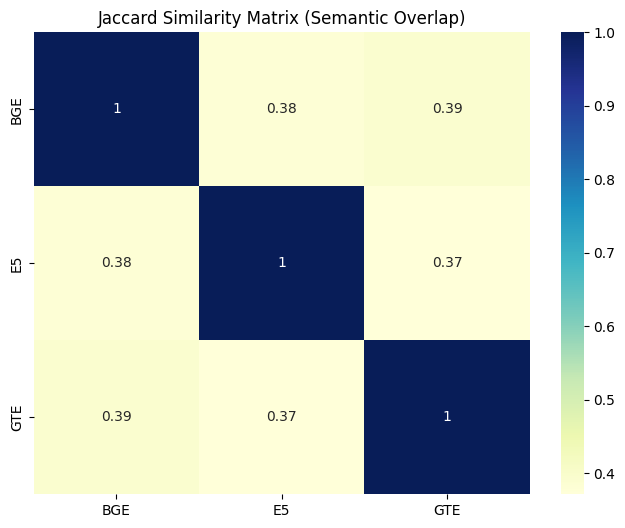

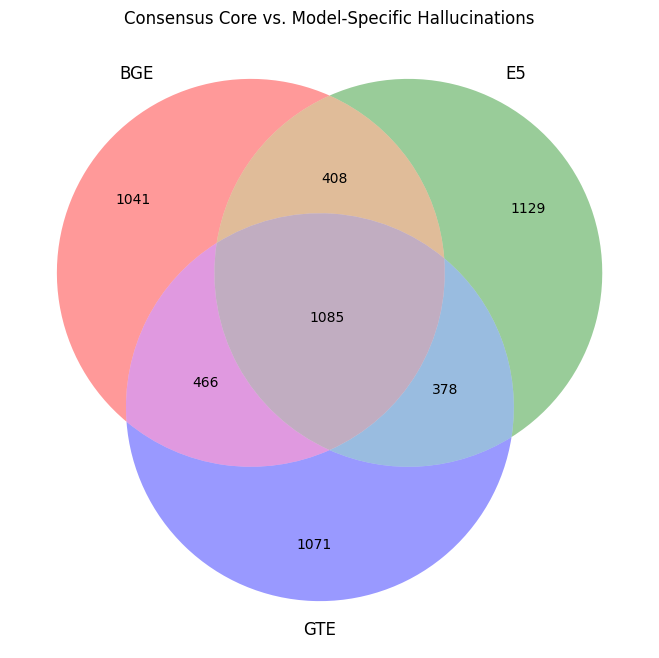

In [39]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from pathlib import Path

# ---- CONFIG ----
BASE_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection")

# Update these to your exact latest filenames
PATHS = {
    "BGE": BASE_DIR / "bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151825_task0_20260205_062714.jsonl",
    "E5":  BASE_DIR / "e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151826_task0_20260205_062733.jsonl",
    "GTE": BASE_DIR / "gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2151827_task0_20260205_062736.jsonl"
}

def load_data(filepath):
    data = {}
    if not filepath.exists(): return data
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            data[obj['job_id']] = set(obj['final'])
    return data

# 1. Load and Intersect
results = {name: load_data(path) for name, path in PATHS.items()}
loaded = [n for n, d in results.items() if d]
common_ids = set.intersection(*[set(results[m].keys()) for m in loaded])

# 2. Extract Commonalities and Differences
report_data = []
for jid in common_ids:
    bge_set = results["BGE"].get(jid, set())
    e5_set = results["E5"].get(jid, set())
    gte_set = results["GTE"].get(jid, set())
    
    # Are they identical?
    all_agree = (bge_set == e5_set == gte_set)
    
    # Who is the outlier?
    outlier = "None"
    if bge_set == e5_set != gte_set: outlier = "GTE"
    elif bge_set == gte_set != e5_set: outlier = "E5"
    elif e5_set == gte_set != bge_set: outlier = "BGE"
    elif not all_agree: outlier = "All Diverged"

    report_data.append({
        "job_id": jid,
        "all_agree": all_agree,
        "outlier": outlier,
        "bge_count": len(bge_set),
        "e5_count": len(e5_set),
        "gte_count": len(gte_set),
        "consensus_count": len(bge_set & e5_set & gte_set)
    })

df = pd.DataFrame(report_data)

# 3. Print Statistical Summary
print("=== COMPREHENSIVE COMPARISON REPORT ===")
print(f"Total Common Jobs: {len(df)}")
print(f"Absolute Consensus: {df['all_agree'].sum()} ({df['all_agree'].mean():.1%})")
print("\n--- Outlier Frequency (Who disagrees with the majority?) ---")
print(df[df['outlier'] != "None"]['outlier'].value_counts())

# 4. Generate Visualizations
# Jaccard Heatmap
model_names = list(results.keys())
j_matrix = np.zeros((3, 3))
for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        scores = [len(results[m1][jid] & results[m2][jid]) / len(results[m1][jid] | results[m2][jid]) 
                  for jid in common_ids]
        j_matrix[i, j] = np.mean(scores)

plt.figure(figsize=(8, 6))
sns.heatmap(j_matrix, annot=True, xticklabels=model_names, yticklabels=model_names, cmap="YlGnBu")
plt.title("Jaccard Similarity Matrix (Semantic Overlap)")
plt.savefig("semantic_overlap_heatmap.png")

# Venn Diagram
venn_sets = []
for name in model_names:
    s = set()
    for jid in common_ids:
        for occ in results[name][jid]:
            s.add(f"{jid}|{occ}")
    venn_sets.append(s)

plt.figure(figsize=(10, 8))
venn3(venn_sets, set_labels=model_names)
plt.title("Consensus Core vs. Model-Specific Hallucinations")
plt.savefig("assignment_venn.png")